# Massachusetts Student Discipline — Geographic Insights
**Data:** MA DESE Student Discipline Data Reports (2020-21, 2022-23, 2023-24, 2024-25)  
**Scope:** ~400 districts, ~950k students  
**Purpose:** Surface location-based patterns in discipline rates across the state



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

# Load all four years
files = {
    '2020-21': 'StudentDisciplineDataReport_2020_to_2021.xlsx',
    '2022-23': 'StudentDisciplineDataReport_2022_to_2023.xlsx',
    '2023-24': 'StudentDisciplineDataReport_2023_to_2024.xlsx',
    '2024-25': 'StudentDisciplineDataReport_2024_to_2025.xlsx',
}

frames = []
for year, fname in files.items():
    df = pd.read_excel(fname, skiprows=1)
    for col in df.columns[2:]:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',','').str.strip(), errors='coerce')
    df['Year'] = year
    frames.append(df)

data = pd.concat(frames, ignore_index=True)
data = data[data['District Name'] != 'State Totals']
data['Discipline Rate'] = data['Students Disciplined'] / data['Students'] * 100

print(f"Loaded {len(data)} district-year rows across {data['District Name'].nunique()} districts")
data.head(3)

Loaded 1593 district-year rows across 413 districts


,District Name,District Code,Students,Students Disciplined,% In-School Suspension,% Out-of-School Suspension,% Expulsion,% Removed to Alternate Setting,% Emergency Removal,% Students with a School-Based Arrest,% Students with a Non-Arrest Law Enforcement Referral,Year,Discipline Rate
0,Abby Kelley Foster Charter Public (District),4450000,1447,43.0,0.4,2.8,0.0,0.0,0.0,0.0,0.0,2020-21,2.971666
1,Abington,10000,2246,77.0,2.1,2.0,0.0,0.0,0.0,0.0,0.0,2020-21,3.428317
2,Academy Of the Pacific Rim Charter Public (Dis...,4120000,534,58.0,3.4,6.6,0.0,0.6,4.3,0.0,0.0,2020-21,10.861423


---
## 1. Gateway Cities vs. Other Districts

Massachusetts officially designates 26 post-industrial cities as "Gateway Cities" (per the MA Executive Office of Housing & Livable Communities). These communities have lower median incomes and higher poverty rates. We compare their discipline rates against all other traditional public districts.

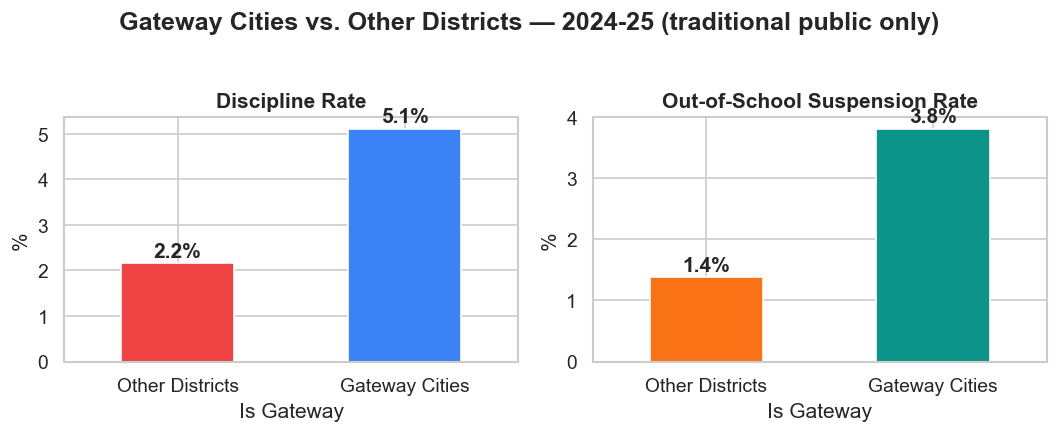

Gateway Cities discipline rate is 2.4x higher than other districts

Gateway: 292,958 students
Other:   584,603 students


In [2]:
# Official MA Gateway Cities list
gateway_cities = ['Boston','Brockton','Chelsea','Chicopee','Everett','Fall River','Fitchburg',
    'Haverhill','Holyoke','Lawrence','Leominster','Lowell','Lynn','Malden','Methuen',
    'New Bedford','Pittsfield','Quincy','Revere','Salem','Springfield','Taunton',
    'Westfield','Worcester']

latest = data[data['Year'] == '2024-25'].copy()

# Exclude charters/vocational for apples-to-apples comparison
mask = ~latest['District Name'].str.contains('Charter|charter|Vocational|vocational', na=False)
latest_trad = latest[mask].copy()
latest_trad['Is Gateway'] = latest_trad['District Name'].isin(gateway_cities)

comp = latest_trad.groupby('Is Gateway').apply(
    lambda g: pd.Series({
        'Discipline Rate': g['Students Disciplined'].sum() / g['Students'].sum() * 100,
        'OSS Rate': (g['% Out-of-School Suspension'] * g['Students'] / 100).sum() / g['Students'].sum() * 100,
        'Students': g['Students'].sum()
    })
)
comp.index = comp.index.map({True: 'Gateway Cities', False: 'Other Districts'})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
comp['Discipline Rate'].plot.bar(ax=axes[0], color=['#ef4444','#3b82f6'], rot=0)
axes[0].set_title('Discipline Rate', fontweight='bold')
axes[0].set_ylabel('%')
for i, v in enumerate(comp['Discipline Rate']):
    axes[0].text(i, v + 0.15, f'{v:.1f}%', ha='center', fontweight='bold')

comp['OSS Rate'].plot.bar(ax=axes[1], color=['#f97316','#0d9488'], rot=0)
axes[1].set_title('Out-of-School Suspension Rate', fontweight='bold')
axes[1].set_ylabel('%')
for i, v in enumerate(comp['OSS Rate']):
    axes[1].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Gateway Cities vs. Other Districts — 2024-25 (traditional public only)', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

ratio = comp.loc['Gateway Cities','Discipline Rate'] / comp.loc['Other Districts','Discipline Rate']
print(f"Gateway Cities discipline rate is {ratio:.1f}x higher than other districts")
print(f"\nGateway: {comp.loc['Gateway Cities','Students']:,.0f} students")
print(f"Other:   {comp.loc['Other Districts','Students']:,.0f} students")

Gateway Cities are an official MA state designation — these 24 city names each match exactly one row in the DESE data, with no geographic inference involved. Charter and vocational schools are excluded to keep the comparison between traditional public districts serving students within city boundaries.

---
## 2. Major City Trends Over Time

These are exact district name matches — each city name corresponds directly to a single row in the data. We track how the largest cities have trended across the four reporting years.

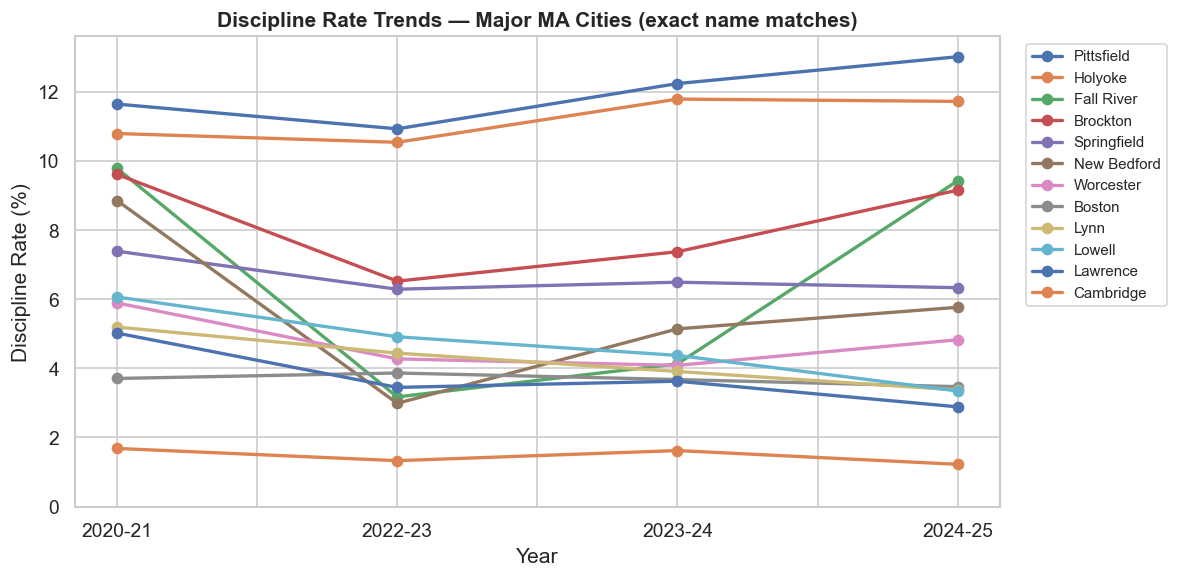

Year           2020-21  2022-23  2023-24  2024-25
District Name                                    
Pittsfield        11.6     10.9     12.2     13.0
Holyoke           10.8     10.5     11.8     11.7
Fall River         9.8      3.2      4.1      9.4
Brockton           9.6      6.5      7.4      9.1
Springfield        7.4      6.3      6.5      6.3
New Bedford        8.8      3.0      5.1      5.8
Worcester          5.9      4.3      4.1      4.8
Boston             3.7      3.9      3.7      3.5
Lynn               5.2      4.4      3.9      3.4
Lowell             6.1      4.9      4.4      3.3
Lawrence           5.0      3.4      3.6      2.9
Cambridge          1.7      1.3      1.6      1.2


In [3]:
cities = ['Boston','Worcester','Springfield','Brockton','Fall River','New Bedford',
          'Lowell','Lawrence','Lynn','Holyoke','Pittsfield','Cambridge']

city_data = data[data['District Name'].isin(cities)].copy()
pivot = city_data.pivot_table(index='District Name', columns='Year', values='Discipline Rate')
pivot = pivot[['2020-21','2022-23','2023-24','2024-25']]
pivot = pivot.sort_values('2024-25', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.T.plot(ax=ax, marker='o', linewidth=2)
ax.set_ylabel('Discipline Rate (%)')
ax.set_title('Discipline Rate Trends — Major MA Cities (exact name matches)', fontweight='bold')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

print(pivot.round(1).to_string())

This chart tracks 12 of Massachusetts' largest and most recognized cities across four school years to show general trend patterns — which cities are improving, worsening, or volatile. The selection is not exhaustive but covers the major population centers, and each name is an exact match to a DESE district row.

---
## 3. Highest-Rate Districts (2024-25)

Top 15 districts by discipline rate among those with 500+ students. Charter vs. traditional is flagged based on whether "Charter" appears in the district name.

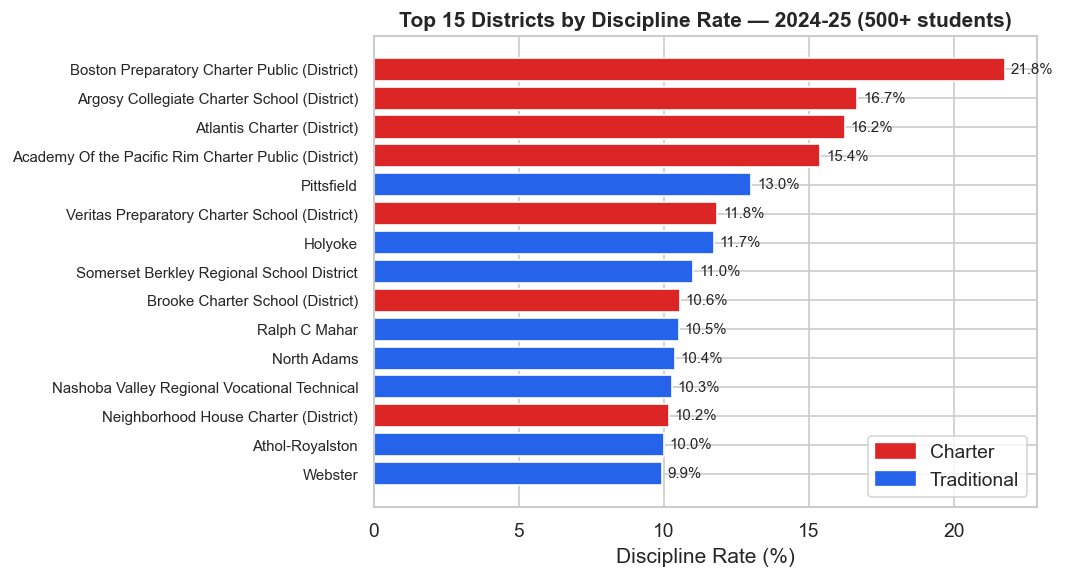

,District,Students,Disc. Rate %,OSS %,ISS %
1,Boston Preparatory Charter Public (District),717,21.8,14.2,0.0
2,Argosy Collegiate Charter School (District),594,16.7,7.7,13.3
3,Atlantis Charter (District),1281,16.2,3.8,15.4
4,Academy Of the Pacific Rim Charter Public (Dis...,533,15.4,13.1,3.8
5,Pittsfield,5081,13.0,7.9,9.8
6,Veritas Preparatory Charter School (District),727,11.8,5.6,8.3
7,Holyoke,5240,11.7,9.6,2.7
8,Somerset Berkley Regional School District,909,11.0,4.0,9.5
9,Brooke Charter School (District),2265,10.6,5.6,6.2
10,Ralph C Mahar,533,10.5,10.5,0.0


In [4]:
top = latest[latest['Students'] >= 500].nlargest(15, 'Discipline Rate')[
    ['District Name','Students','Discipline Rate','% Out-of-School Suspension','% In-School Suspension']
].reset_index(drop=True)
top.index = top.index + 1
top.columns = ['District','Students','Disc. Rate %','OSS %','ISS %']

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#dc2626' if 'Charter' in str(d) or 'charter' in str(d) else '#2563eb' for d in top['District']]
ax.barh(range(len(top)), top['Disc. Rate %'], color=colors)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['District'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Discipline Rate (%)')
ax.set_title('Top 15 Districts by Discipline Rate — 2024-25 (500+ students)', fontweight='bold')
for i, v in enumerate(top['Disc. Rate %']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend([Patch(color='#dc2626'), Patch(color='#2563eb')], ['Charter', 'Traditional'], loc='lower right')
plt.tight_layout()
plt.show()

top.round(1)

This ranks all districts in 2024-25 by discipline rate, filtered to those with 500+ students to avoid small-sample outliers. Discipline rate represents the percentage of enrolled students in a district who received at least one disciplinary action in a given school year.

---
## 4. Affluent Suburbs vs. Urban Centers

All names below are exact district name matches. Affluent suburbs are selected based on well-known high-income MA communities. Urban centers are drawn from the Gateway Cities list.

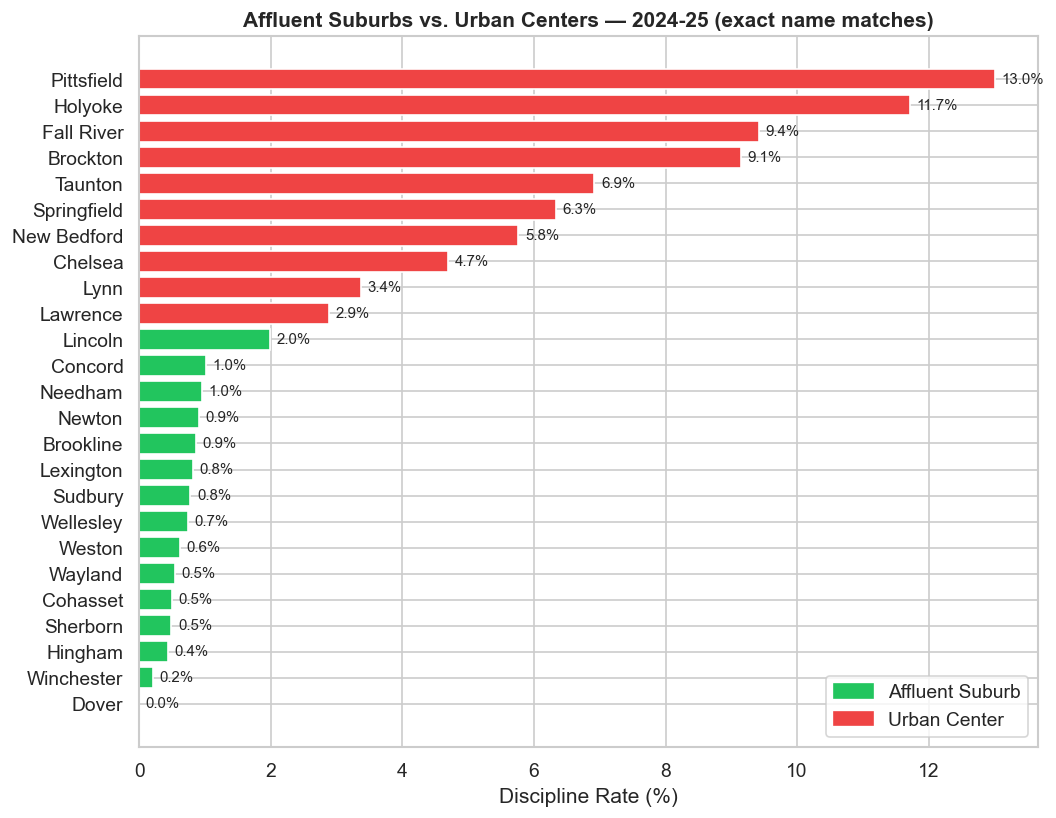

Affluent suburbs average: 0.8%
Urban centers average: 6.6%
Urban centers are 9x higher


In [5]:
affluent = ['Wellesley','Weston','Dover','Concord','Lincoln','Lexington','Newton',
            'Brookline','Needham','Winchester','Hingham','Cohasset','Wayland','Sudbury','Sherborn']
urban = ['Springfield','Holyoke','Pittsfield','Brockton','Fall River','New Bedford',
         'Lawrence','Chelsea','Lynn','Taunton']

aff_data = latest[latest['District Name'].isin(affluent)].copy()
urb_data = latest[latest['District Name'].isin(urban)].copy()

combined_plot = pd.concat([
    aff_data[['District Name','Discipline Rate']].assign(Group='Affluent Suburb'),
    urb_data[['District Name','Discipline Rate']].assign(Group='Urban Center')
]).sort_values('Discipline Rate', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#22c55e' if g == 'Affluent Suburb' else '#ef4444' for g in combined_plot['Group']]
ax.barh(combined_plot['District Name'], combined_plot['Discipline Rate'], color=colors)
ax.set_xlabel('Discipline Rate (%)')
ax.set_title('Affluent Suburbs vs. Urban Centers — 2024-25 (exact name matches)', fontweight='bold')
for i, (_, row) in enumerate(combined_plot.iterrows()):
    ax.text(row['Discipline Rate'] + 0.1, i, f"{row['Discipline Rate']:.1f}%", va='center', fontsize=9)

from matplotlib.patches import Patch
ax.legend([Patch(color='#22c55e'), Patch(color='#ef4444')], ['Affluent Suburb', 'Urban Center'], loc='lower right')
plt.tight_layout()
plt.show()

aff_avg = aff_data['Students Disciplined'].sum() / aff_data['Students'].sum() * 100
urb_avg = urb_data['Students Disciplined'].sum() / urb_data['Students'].sum() * 100
print(f"Affluent suburbs average: {aff_avg:.1f}%")
print(f"Urban centers average: {urb_avg:.1f}%")
print(f"Urban centers are {urb_avg/aff_avg:.0f}x higher")

Urban centers are drawn from the official Gateway Cities list, but the "affluent suburb" label is not a state designation — it reflects well-known high-income communities that could be verified against Census median household income data. All 25 names are exact matches to district rows in the data.


---
## 5. Biggest Shifts Over Time (2020-21 → 2024-25)

Districts with the largest changes in discipline rate. Only includes districts with 300+ students in both years.

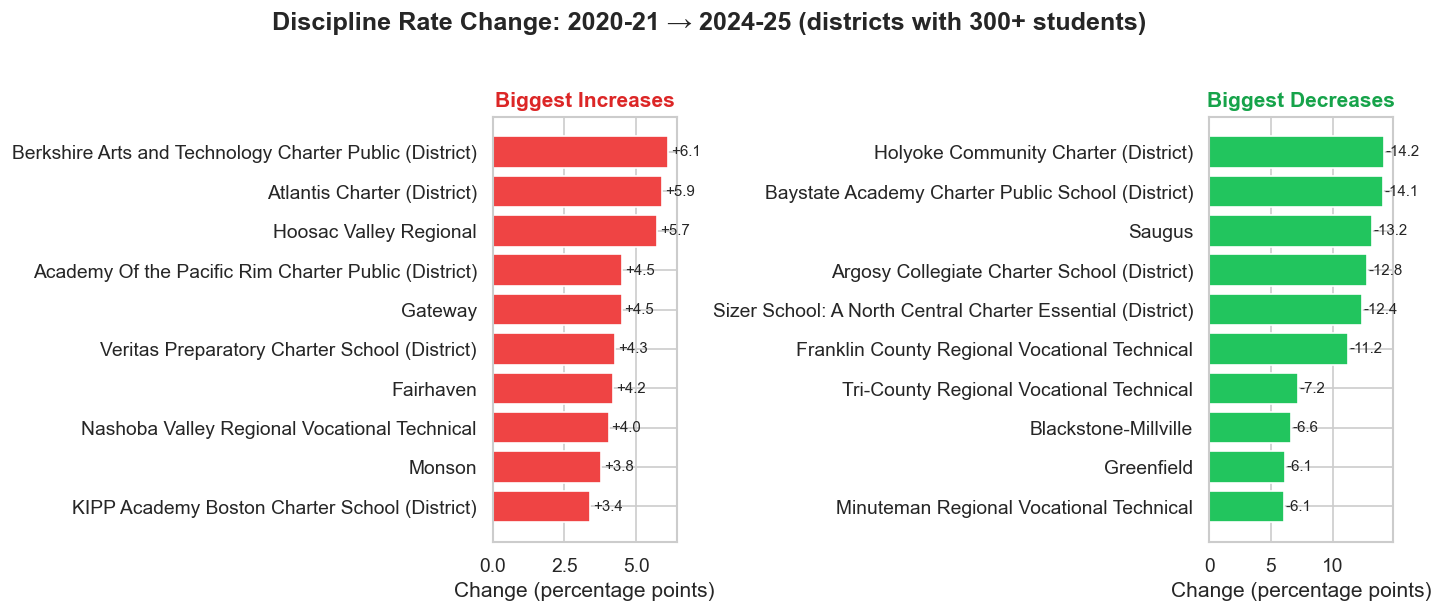

In [6]:
first_yr = data[data['Year'] == '2020-21'][['District Name','Students','Discipline Rate']].rename(
    columns={'Discipline Rate':'Rate 2021','Students':'N 2021'})
last_yr = data[data['Year'] == '2024-25'][['District Name','Students','Discipline Rate']].rename(
    columns={'Discipline Rate':'Rate 2025','Students':'N 2025'})

changes = first_yr.merge(last_yr, on='District Name')
changes = changes[(changes['N 2021'] >= 300) & (changes['N 2025'] >= 300)]
changes['Change (pp)'] = changes['Rate 2025'] - changes['Rate 2021']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

inc = changes.nlargest(10, 'Change (pp)')
axes[0].barh(inc['District Name'], inc['Change (pp)'], color='#ef4444')
axes[0].invert_yaxis()
axes[0].set_xlabel('Change (percentage points)')
axes[0].set_title('Biggest Increases', fontweight='bold', color='#dc2626')
for i, (_, r) in enumerate(inc.iterrows()):
    axes[0].text(r['Change (pp)'] + 0.1, i, f"+{r['Change (pp)']:.1f}", va='center', fontsize=9)

dec = changes.nsmallest(10, 'Change (pp)')
dec = dec.copy()
dec['Abs Change'] = dec['Change (pp)'].abs()
axes[1].barh(dec['District Name'], dec['Abs Change'], color='#22c55e')
axes[1].invert_yaxis()
axes[1].set_xlabel('Change (percentage points)')
axes[1].set_title('Biggest Decreases', fontweight='bold', color='#16a34a')
for i, (_, r) in enumerate(dec.iterrows()):
    axes[1].text(r['Abs Change'] + 0.1, i, f"{r['Change (pp)']:.1f}", va='center', fontsize=9)

plt.suptitle('Discipline Rate Change: 2020-21 → 2024-25 (districts with 300+ students)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

This joins 2020-21 to 2024-25 data on exact district name and computes the percentage-point change, with a 300-student minimum in both years to filter out small districts where a few incidents would create misleading swings. No aggregation or grouping is applied — each bar is a single district.

---
## 6. Out-of-School Suspension Heatmap — Major Cities

OSS is the most consequential discipline type (students lose instructional time). All city names are exact matches to district names in the data.

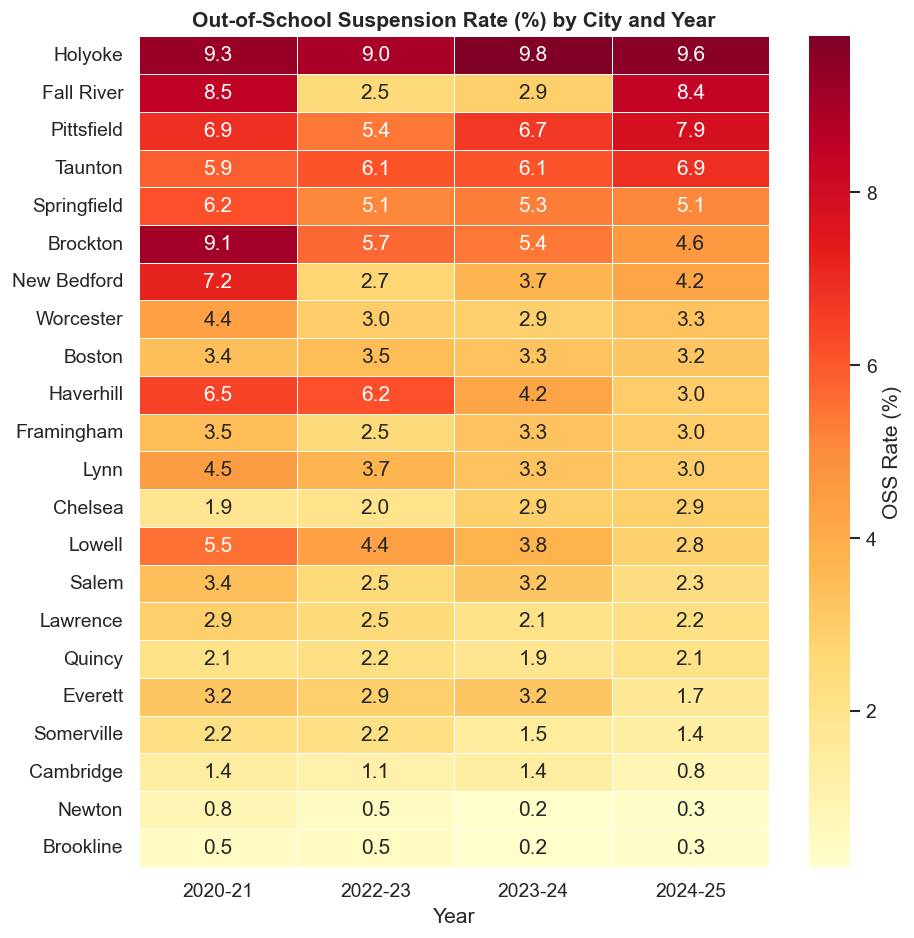

In [7]:
cities_oss = ['Pittsfield','Holyoke','Springfield','Brockton','Fall River','New Bedford',
              'Taunton','Chelsea','Everett','Worcester','Framingham','Lowell','Lynn',
              'Lawrence','Boston','Haverhill','Salem','Somerville','Quincy','Cambridge',
              'Brookline','Newton']

oss_data = data[data['District Name'].isin(cities_oss)].pivot_table(
    index='District Name', columns='Year', values='% Out-of-School Suspension')
oss_data = oss_data[['2020-21','2022-23','2023-24','2024-25']]
oss_data = oss_data.sort_values('2024-25', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(oss_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'OSS Rate (%)'}, ax=ax)
ax.set_title('Out-of-School Suspension Rate (%) by City and Year', fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

The values come directly from DESE's "% Out-of-School Suspension" column — the notebook reads them as-is rather than calculating them. Each of the 22 city names matches exactly one district row per year.

---
## Key Takeaways

1. **Gateway Cities** discipline at ~2.4x the rate of other traditional public districts, with an even wider gap in out-of-school suspensions
2. **Pittsfield and Holyoke** are persistent hotspots — both above 11% every year measured, and Pittsfield is worsening
3. **Affluent suburbs** (Dover, Winchester, Wellesley, etc.) sit at 0–1%, creating a 10–20x gap vs. urban centers
4. **Fall River and Brockton** show volatile, unstable patterns 
5. **Lowell, Lawrence, and Lynn** show steady improvement; potential models for effective intervention
6. **Charter schools** dominate the high end of discipline rates — 8 of the top 12 highest-rate districts are charters